In [1]:
import json

In [2]:
with open("2-processed/native_mcqs.json", "r") as f:
    data = json.load(f)

In [3]:
len(data)

8688

In [4]:
FINAL_DOMAINS = {"STEM", "Humanities", "Social Sciences", "Profession", "Other"}

In [5]:
unique_subdomains = set()
for item in data:
    unique_subdomains.add(item["subdomain"])

unique_subdomains

{'clerical services',
 'computer science',
 'current and international affairs',
 'education',
 'federal investigation law',
 'general knowledge',
 'general science',
 'hajj management',
 'islamic studies',
 'mathematics',
 'pakistan studies',
 'physics',
 'professional development',
 'psychology',
 'psychometrics',
 'urdu grammar',
 'urdu language',
 'urdu literature'}

In [6]:
# Explicit subdomain → final domain mapping.
# Takes priority over any existing domain value on the item.
SUBDOMAIN_TO_DOMAIN = {
    # ── Humanities ──────────────────────────────────────────────────────────
    "islamic_studies":          "Humanities",
    "islamic studies":          "Humanities",
    "islamiat":                 "Humanities",
    "tarjamatul_quran":         "Humanities",
    "tarjamatul quran":         "Humanities",
    "ethics":                   "Humanities",
    "urdu language":            "Humanities",
    "urdu_literature":          "Humanities",
    "urdu literature":          "Humanities",
    "urdu grammar":             "Humanities",
    "art and drawing":          "Humanities",

    # ── STEM ────────────────────────────────────────────────────────────────
    "biology":                      "STEM",
    "chemistry":                    "STEM",
    "physics":                      "STEM",
    "mathematics":                  "STEM",
    "computer science":             "STEM",
    "general science":              "STEM",
    "high_school_computer_science": "STEM",
    "electrical_engineering":       "STEM",
    "elementary_mathematics":       "STEM",
    "everyday_science":             "STEM",

    # ── Social Sciences ─────────────────────────────────────────────────────
    "pakistan studies":                "Social Sciences",
    "civics":                        "Social Sciences",
    "pedagogy":                      "Social Sciences",
    "psychometrics":                 "Social Sciences",
    "health_and_physical_education": "Social Sciences",
    "health and physical education": "Social Sciences",
    "education":                     "Social Sciences",
    "current_affairs":               "Social Sciences",
    "international_affairs":         "Social Sciences",
    "social_studies":                "Social Sciences",
    "economics":                     "Social Sciences",
    "geography":                     "Social Sciences",
    "commerce":                      "Social Sciences",
    "psychology and clinical education": "Social Sciences",
    "psychology":                     "Social Sciences",
    "sociology":                     "Social Sciences",
    "current and international affairs": "Social Sciences",

    # ── Profession ──────────────────────────────────────────────────────────
    "hajj management":                    "Profession",
    "professional_development":           "Profession",
    "clerical services":                  "Profession",
    "clothing_and_textile":               "Profession",
    "dress_making_and_fashion_designing": "Profession",
    "electrical_and_wiring":             "Profession",
    "food_and_nutrition":                 "Profession",
    "home economics":                     "Profession",
    "internet_of_things":                 "Profession",
    "media_production":                   "Profession",
    "media production":                   "Profession",
    "plumbing_and_solar_water_heating":   "Profession",
    "plumbing":                           "Profession",
    "tourism":                            "Profession",
    "tourism management":                "Profession",

    # ── Other ────────────────────────────────────────────────────────────────
    "general knowledge":         "Other",
    "federal investigation law": "Other",
    "professional_psychology":   "Other",
    "professional development":   "Other",
}

In [7]:
# based on the above mapping, assign final domain to each item in the dataset based on its subdomain
for item in data:
    subdomain = item["subdomain"]
    if subdomain in SUBDOMAIN_TO_DOMAIN:
        item["domain"] = SUBDOMAIN_TO_DOMAIN[subdomain]
    else:
        item["domain"] = "NO DOMAIN"

In [8]:
# find samples where domain is NO DOMAIN
no_domain_samples = [item for item in data if item["domain"] == "NO DOMAIN"]
len(no_domain_samples)

0

In [9]:
no_domain_samples

[]

In [10]:
# add id key starting from 0
for i, item in enumerate(data):
    item["id"] = i

In [11]:
data[0]

{'question': 'ہوا میں کونسی گیس ہوتی ہے؟',
 'options': {'A': 'نائٹروجن',
  'B': 'آکسیجن',
  'C': 'کاربن ڈائی آکسائیڈ',
  'D': 'ہائیڈروجن'},
 'correct_index': 0,
 'subdomain': 'general science',
 'domain': 'STEM',
 'source': 'etest',
 'level': '',
 'source_url': 'https://etest.com.pk/category/everyday-science-mcqs/',
 'correct_option': 'A',
 'id': 0}

In [12]:
# reaarrnge the keys in each item to have id as the first key, followed rest
for item in data:
    item["id"] = item.pop("id")
    item["question"] = item.pop("question")
    item["options"] = item.pop("options")
    item["domain"] = item.pop("domain")
    item["subdomain"] = item.pop("subdomain")
    item["correct_option"] = item.pop("correct_option")
    item["correct_index"] = item.pop("correct_index")
    item["level"] = item.pop("level")
    item["source_url"] = item.pop("source_url")
    item["source"] = item.pop("source")

In [13]:
data[0]

{'id': 0,
 'question': 'ہوا میں کونسی گیس ہوتی ہے؟',
 'options': {'A': 'نائٹروجن',
  'B': 'آکسیجن',
  'C': 'کاربن ڈائی آکسائیڈ',
  'D': 'ہائیڈروجن'},
 'domain': 'STEM',
 'subdomain': 'general science',
 'correct_option': 'A',
 'correct_index': 0,
 'level': '',
 'source_url': 'https://etest.com.pk/category/everyday-science-mcqs/',
 'source': 'etest'}

In [14]:
# remove STEM domain samples as the STEM is very basic in native mcqs file
data = [item for item in data if item["domain"] != "STEM"]

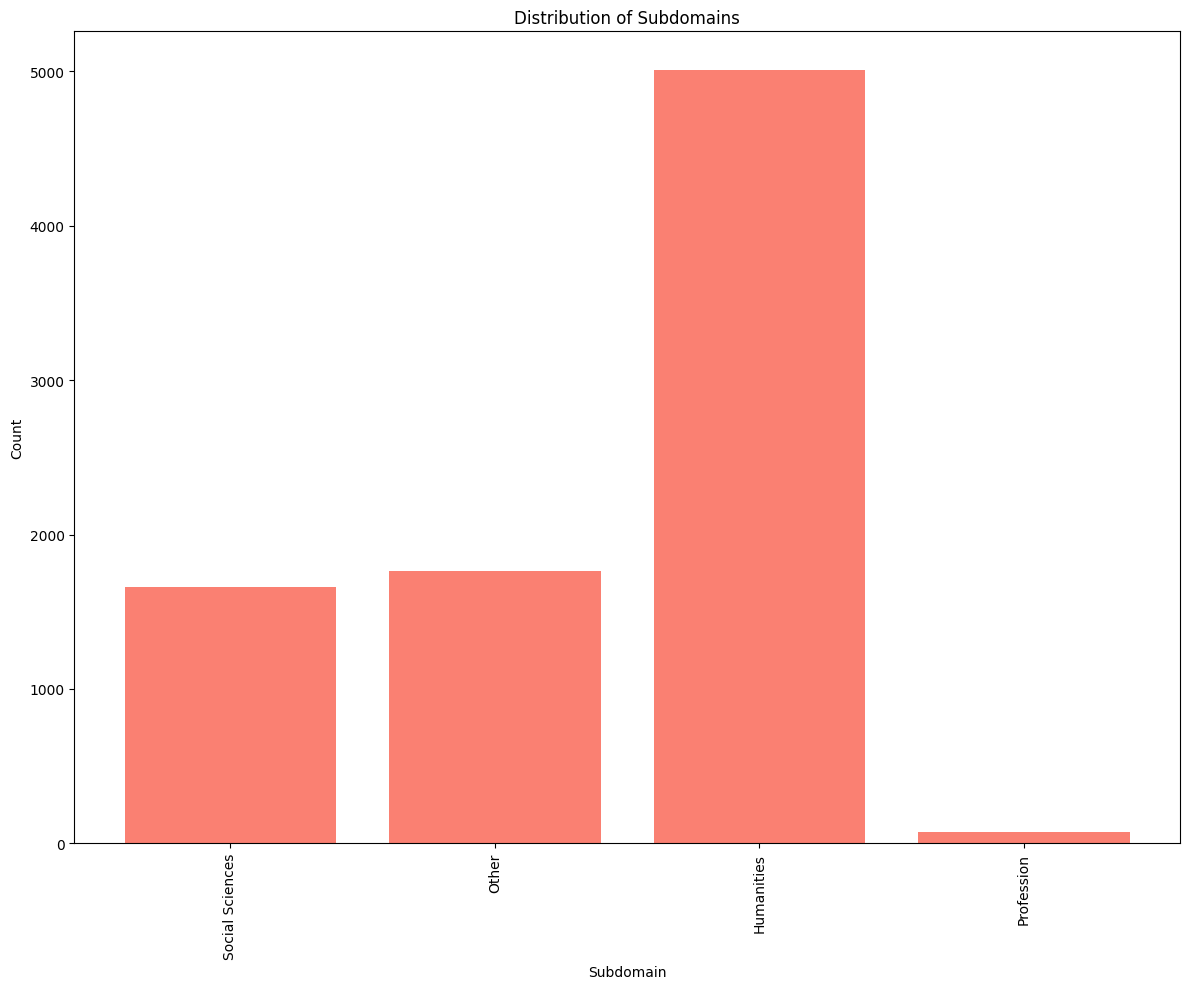

In [15]:
import matplotlib.pyplot as plt
from collections import Counter

subdomains = [item['domain'] for item in data]
subdomain_counts = Counter(subdomains)

# rotate x-axis labels for better readability to 90 degrees
plt.figure(figsize=(12, 10))
plt.bar(subdomain_counts.keys(), subdomain_counts.values(), color='salmon')
plt.title('Distribution of Subdomains')
plt.xlabel('Subdomain')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [16]:
with open('2-processed/native_mcqs.json', 'w', encoding='utf-8') as f:
    json.dump(data, f, ensure_ascii=False, indent=4)